# Chapter 11. 토치 커넥터(TorchConnector)와 하이브리드 양자-고전 신경망(Hybrid QNN)

이 튜토리얼은 `토치 커넥터(TorchConnector)` 클래스를 소개하며, 이것이 Qiskit 머신러닝의 모든 `신경망(NeuralNetwork)`을 파이토치(PyTorch) 워크플로우에 자연스럽게 통합할 수 있음을 보여준다. `토치 커넥터(TorchConnector)`는 `신경망(NeuralNetwork)`을 받아 파이토치 `모듈(Module)`로 사용 가능하게 만든다. 결과 모듈은 파이토치 고전 아키텍처에 완벽하게 통합될 수 있으며 추가 고려 없이 함께 훈련될 수 있으므로 새로운 **하이브리드 양자-고전(hybrid quantum-classical)** 머신러닝 아키텍처의 개발 및 테스트가 가능해진다.

## 내용(Content):

[파트 1: 단순 분류 및 회귀](#Part-1:-Simple-Classification-&-Regression)

이 튜토리얼의 첫 번째 부분은 양자 신경망이 단순 분류 및 회귀 작업을 위해 파이토치의 자동 미분 엔진(`torch.autograd`, [링크](https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html))을 사용하여 어떻게 훈련될 수 있는지를 보여준다.

1. [분류(Classification)](#1.-Classification)
    1. 파이토치와 `추정기QNN(EstimatorQNN)`을 이용한 분류
    2. 파이토치와 `샘플러QNN(SamplerQNN)`을 이용한 분류
2. [회귀(Regression)](#2.-Regression)
    1. 파이토치와 `추정기QNN(EstimatorQNN)`을 이용한 회귀

[파트 2: MNIST 분류, 하이브리드 양자-고전 신경망](#Part-2:-MNIST-Classification,-Hybrid-QNNs)

이 튜토리얼의 두 번째 부분은 (양자) `신경망(NeuralNetwork)`을 목표 파이토치 워크플로우(이 경우, 일반적인 CNN 아키텍처)에 포함시켜 MNIST 데이터를 하이브리드 양자-고전 방식으로 분류하는 방법을 보여준다.

***

In [3]:
%pip install -q torch==2.7.0 torchvision==0.22.0 torchaudio==2.7.0

Note: you may need to restart the kernel to use updated packages.


In [4]:
# 필수 라이브러리 임포트(numpy, matplotlib, torch, qiskit)
# Necessary imports

import numpy as np
import matplotlib.pyplot as plt

from torch import Tensor
from torch.nn import Linear, CrossEntropyLoss, MSELoss
from torch.optim import LBFGS

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import real_amplitudes, zz_feature_map
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# Set seed for random generators
algorithm_globals.random_seed = 42

## 파트 1: 단순 분류 및 회귀(Part 1: Simple Classification & Regression)

### 1. 분류(Classification)

먼저, `토치 커넥터(TorchConnector)`가 파이토치의 자동 미분 엔진을 사용하여 분류 작업을 해결하는 양자 `신경망(NeuralNetwork)`을 훈련할 수 있는 방법을 보여준다. 이를 설명하기 위해, 무작위로 생성된 데이터셋에 대해 **이진 분류(binary classification)**를 수행할 것이다.

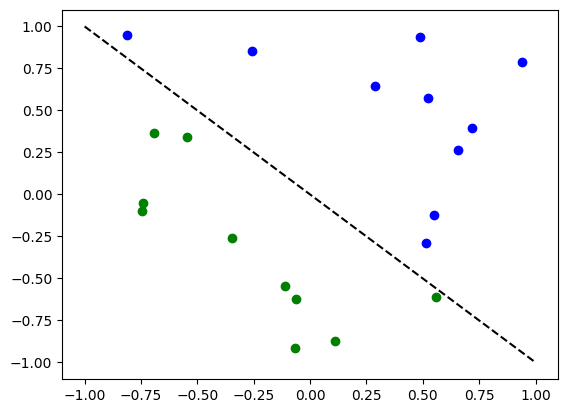

In [5]:
# 무작위 데이터셋 생성(num_inputs=2, num_samples=20)
# Generate random dataset

# Select dataset dimension (num_inputs) and size (num_samples)
num_inputs = 2
num_samples = 20

# Generate random input coordinates (X) and binary labels (y)
X = 2 * algorithm_globals.random.random([num_samples, num_inputs]) - 1
y01 = 1 * (np.sum(X, axis=1) >= 0)  # in { 0,  1}, y01 will be used for SamplerQNN example
y = 2 * y01 - 1  # in {-1, +1}, y will be used for EstimatorQNN example

# Convert to torch Tensors
X_ = Tensor(X)
y01_ = Tensor(y01).reshape(len(y)).long()
y_ = Tensor(y).reshape(len(y), 1)

# Plot dataset
for x, y_target in zip(X, y):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

#### A. 파이토치와 `추정기QNN(EstimatorQNN)`을 이용한 분류

`추정기QNN(EstimatorQNN)`을 파이토치에 연결하는 것은 상대적으로 간단하다. 여기서는 피처 맵(feature map)과 앤자츠(ansatz)로 구성된 `추정기QNN(EstimatorQNN)`을 사용하여 이를 설명한다.

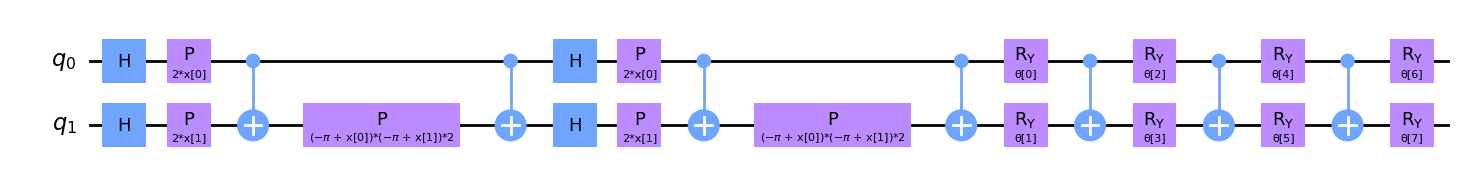

In [6]:
# 회로 설정(피처 맵, 앤자츠, 양자 회로)
# Set up a circuit
feature_map = zz_feature_map(num_inputs)
ansatz = real_amplitudes(num_inputs)
qc = QuantumCircuit(num_inputs)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)
qc.draw(output="mpl", style="clifford")

In [7]:
# 상태벡터 추정기(StatevectorEstimator)를 이용한 추정기QNN 설정
from qiskit.primitives import StatevectorEstimator as Estimator

estimator = Estimator()
# Setup QNN
qnn1 = EstimatorQNN(
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator,
)

# Set up PyTorch module
# Note: If we don't explicitly declare the initial weights
# they are chosen uniformly at random from [-1, 1].
initial_weights = 0.1 * (2 * algorithm_globals.random.random(qnn1.num_weights) - 1)
model1 = TorchConnector(qnn1, initial_weights=initial_weights)
print("Initial weights: ", initial_weights)

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Initial weights:  [-0.01256962  0.06653564  0.04005302 -0.03752667  0.06645196  0.06095287
 -0.02250432 -0.04233438]


In [8]:
# 단일 입력으로 모델 테스트(model1(X_[0, :]))
# Test with a single input
model1(X_[0, :])

tensor([-0.3202], grad_fn=<_TorchNNFunctionBackward>)

##### 최적화기(Optimizer)
머신러닝 모델을 훈련할 때 최적화 알고리즘의 선택은 훈련 결과의 성공을 결정하는 데 중요할 수 있다. `토치 커넥터(TorchConnector)`를 사용할 때, 우리는 [`torch.optim`] 패키지([ 링크](https://pytorch.org/docs/stable/optim.html))에서 정의된 모든 최적화 알고리즘에 접근할 수 있다. 인기 있는 머신러닝 아키텍처에서 사용되는 가장 유명한 알고리즘 중 일부는 *Adam*, *SGD*, *Adagrad*가 있다. 하지만 이 튜토리얼에서는 L-BFGS 알고리즘(`torch.optim.LBFGS`)을 사용할 것이며, 이는 수치 최적화를 위해 가장 잘 알려진 2차 최적화 알고리즘 중 하나이다.

##### 손실 함수(Loss Function)
손실 함수의 경우, `torch.nn`에서 [Cross-Entropy](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)나 [평균 제곱 오차(Mean Squared Error)](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html) 손실과 같은 미리 정의된 모듈을 활용할 수도 있다.


**💡 명확화(Clarification):** 
고전 머신러닝에서 일반적인 경험칙은 분류 작업에 Cross-Entropy 손실을, 회귀 작업에 MSE 손실을 적용하는 것이다. 하지만 이 권장사항은 분류 네트워크의 출력이 $[0, 1]$ 범위의 클래스 확률 값이라는 가정 하에 주어진다(보통 Softmax 계층을 통해 달성된다). 다음 `추정기QNN(EstimatorQNN)` 예제는 그러한 계층을 포함하지 않으며, 출력에 어떤 매핑도 적용하지 않으므로(다음 섹션은 `샘플러QNN(SamplerQNN)`과 함께 parity 매핑의 적용 예를 보여준다), QNN의 출력은 $[-1, 1]$ 범위의 모든 값을 가질 수 있다. 당신이 궁금해한다면, 이것이 이 특정 예제가 분류에 대해 MSELoss를 사용하는 이유이다(비록 그것이 표준이 아니지만, 다양한 손실 함수를 시도하고 훈련 결과에 어떤 영향을 미칠 수 있는지 보기를 권장한다).

In [9]:
# 최적화기(LBFGS), 손실 함수(MSELoss), 훈련 루프 정의
# Define optimizer and loss
optimizer = LBFGS(model1.parameters())
f_loss = MSELoss(reduction="sum")

# Start training
model1.train()  # set model to training mode


# Note from (https://pytorch.org/docs/stable/optim.html):
# Some optimization algorithms such as LBFGS need to
# reevaluate the function multiple times, so you have to
# pass in a closure that allows them to recompute your model.
# The closure should clear the gradients, compute the loss,
# and return it.
def closure():
    optimizer.zero_grad()  # Initialize/clear gradients
    loss = f_loss(model1(X_), y_)  # Evaluate loss function
    loss.backward()  # Backward pass
    print(loss.item())  # Print loss
    return loss


# Run optimizer step4
optimizer.step(closure)

25.260231018066406
22.714740753173828
20.124088287353516
19.655994415283203
19.125999450683594
20.55582046508789
18.420368194580078
17.573528289794922
16.934314727783203
16.735431671142578
17.301990509033203
15.923425674438477
15.04001522064209
14.98585319519043
14.888829231262207
14.732454299926758
14.858772277832031
14.883110046386719
14.928327560424805
14.874017715454102


tensor(25.2602, grad_fn=<MseLossBackward0>)

Accuracy: 0.8


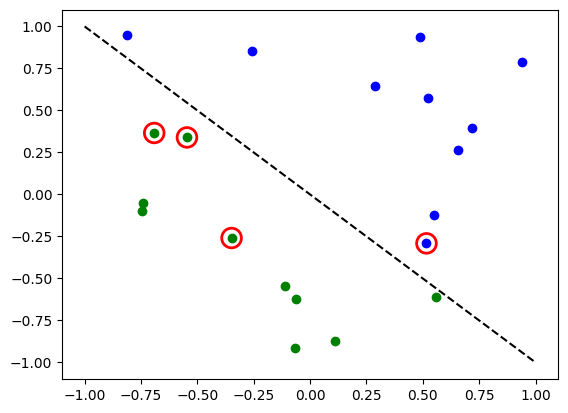

In [10]:
# 모델 평가, 정확도 계산, 그래프 그리기
# Evaluate model and compute accuracy
model1.eval()
y_predict = []
for x, y_target in zip(X, y):
    output = model1(Tensor(x))
    y_predict += [np.sign(output.detach().numpy())[0]]

print("Accuracy:", sum(y_predict == y) / len(y))

# Plot results
# red == wrongly classified
for x, y_target, y_p in zip(X, y, y_predict):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if y_target != y_p:
        plt.scatter(x[0], x[1], s=200, facecolors="none", edgecolors="r", linewidths=2)
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

빨간 원은 잘못 분류된 데이터 포인트를 나타낸다.

#### B. 파이토치와 `샘플러QNN(SamplerQNN)`을 이용한 분류

`샘플러QNN(SamplerQNN)`을 파이토치에 연결하려면 `추정기QNN(EstimatorQNN)`보다 더 많은 주의가 필요하다. 올바른 설정이 없으면 역전파(backpropagation)가 불가능하다.

특히, 네트워크의 순전파(forward pass)에서 확률의 조밀한 배열을 반환하고 있는지 확인해야 한다(`sparse=False`). 이 매개변수는 기본적으로 `False`로 설정되어 있으므로 변경되지 않았는지 확인하면 된다.

**⚠️ 주의(Attention):** 
사용자 정의 해석 함수를 정의하면(예제에서: `parity`), 원하는 출력 형태를 명시적으로 제공해야 한다는 것을 기억해야 한다(예제에서: `2`). `샘플러QNN(SamplerQNN)`의 초기 매개변수 설정에 대한 자세한 정보는 [공식 qiskit 문서](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.neural_networks.SamplerQNN.html)를 확인하시오.

In [11]:
# parity 해석 함수를 이용한 샘플러QNN 설정
# Define feature map and ansatz
feature_map = zz_feature_map(num_inputs)
ansatz = real_amplitudes(num_inputs, entanglement="linear", reps=1)

# Define quantum circuit of num_qubits = input dim
# Append feature map and ansatz
qc = QuantumCircuit(num_inputs)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()

# Define SamplerQNN and initial setup
parity = lambda x: "{:b}".format(x).count("1") % 2  # optional interpret function
output_shape = 2  # parity = 0, 1
qnn2 = SamplerQNN(
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    interpret=parity,
    output_shape=output_shape,
    sampler=sampler,
)

# Set up PyTorch module
# Reminder: If we don't explicitly declare the initial weights
# they are chosen uniformly at random from [-1, 1].
initial_weights = 0.1 * (2 * algorithm_globals.random.random(qnn2.num_weights) - 1)
print("Initial weights: ", initial_weights)
model2 = TorchConnector(qnn2, initial_weights)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Initial weights:  [ 0.0364991  -0.0720495  -0.06001836 -0.09852755]


최적화기와 손실 함수 선택에 대한 상기는 [이 섹션](#Optimizer)으로 돌아갈 수 있다.

In [12]:
# model2 정의, 최적화기, CrossEntropyLoss, 훈련
# Define model, optimizer, and loss
optimizer = LBFGS(model2.parameters())
f_loss = CrossEntropyLoss()  # Our output will be in the [0,1] range

# Start training
model2.train()


# Define LBFGS closure method (explained in previous section)
def closure():
    optimizer.zero_grad(set_to_none=True)  # Initialize gradient
    loss = f_loss(model2(X_), y01_)  # Calculate loss
    loss.backward()  # Backward pass

    print(loss.item())  # Print loss
    return loss


# Run optimizer (LBFGS requires closure)
optimizer.step(closure);

0.7012121081352234
0.6863499879837036
0.6641070246696472
0.6491061449050903
0.6471383571624756
0.6417368650436401
0.6382681131362915
0.7084527015686035
0.6344069242477417
0.6238328218460083
0.6153272390365601
0.6131056547164917
0.6172008514404297
0.6176509261131287
0.6168648600578308
0.6179609894752502
0.6233335733413696
0.6124599575996399
0.6216064691543579
0.615670919418335


Accuracy: 0.8


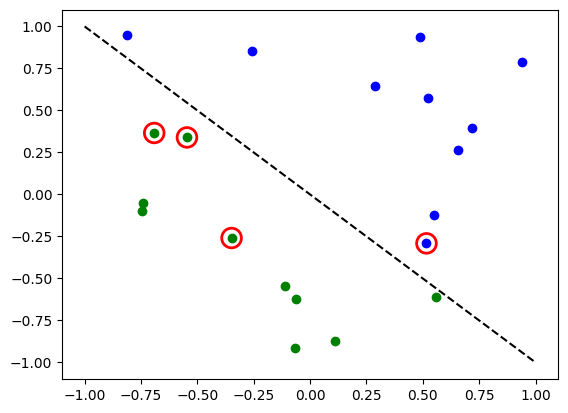

In [13]:
# model2 평가, 정확도 계산, 그래프 그리기
# Evaluate model and compute accuracy
model2.eval()
y_predict = []
for x in X:
    output = model2(Tensor(x))
    y_predict += [np.argmax(output.detach().numpy())]

print("Accuracy:", sum(y_predict == y01) / len(y01))

# plot results
# red == wrongly classified
for x, y_target, y_ in zip(X, y01, y_predict):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if y_target != y_:
        plt.scatter(x[0], x[1], s=200, facecolors="none", edgecolors="r", linewidths=2)
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

빨간 원은 잘못 분류된 데이터 포인트를 나타낸다.

### 2. 회귀(Regression)

우리는 `추정기QNN(EstimatorQNN)`에 기반한 모델을 사용하여 회귀 작업을 수행하는 방법도 보여준다. 이 경우 선택된 데이터셋은 사인파(sine wave)를 따르는 무작위로 생성된다.

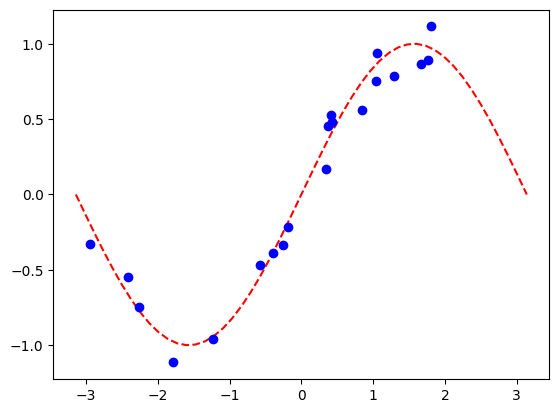

In [14]:
# 회귀 데이터셋 생성(사인 함수)
# Generate random dataset

num_samples = 20
eps = 0.2
lb, ub = -np.pi, np.pi
f = lambda x: np.sin(x)

X = (ub - lb) * algorithm_globals.random.random([num_samples, 1]) + lb
y = f(X) + eps * (2 * algorithm_globals.random.random([num_samples, 1]) - 1)
plt.plot(np.linspace(lb, ub), f(np.linspace(lb, ub)), "r--")
plt.plot(X, y, "bo")
plt.show()

#### A. 파이토치와 `추정기QNN(EstimatorQNN)`을 이용한 회귀

네트워크 정의와 훈련 루프는 `추정기QNN(EstimatorQNN)`을 사용한 분류 작업과 유사할 것이다. 이 경우, 우리는 우리의 고유한 피처 맵과 앤자츠를 정의하지만, 조금 다르게 해보자.

In [15]:
# 피처 맵, 앤자츠, 추정기QNN, model3 구성
# Construct simple feature map
param_x = Parameter("x")
feature_map = QuantumCircuit(1, name="fm")
feature_map.ry(param_x, 0)

# Construct simple parameterized ansatz
param_y = Parameter("y")
ansatz = QuantumCircuit(1, name="vf")
ansatz.ry(param_y, 0)

qc = QuantumCircuit(1)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

# Construct QNN
qnn3 = EstimatorQNN(
    circuit=qc, input_params=[param_x], weight_params=[param_y], estimator=estimator
)

# Set up PyTorch module
# Reminder: If we don't explicitly declare the initial weights
# they are chosen uniformly at random from [-1, 1].
initial_weights = 0.1 * (2 * algorithm_globals.random.random(qnn3.num_weights) - 1)
model3 = TorchConnector(qnn3, initial_weights)

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


최적화기와 손실 함수 선택에 대한 상기는 [이 섹션](#Optimizer)으로 돌아갈 수 있다.

In [16]:
# 최적화기(LBFGS), MSELoss, 훈련 루프 정의
# Define optimizer and loss function
optimizer = LBFGS(model3.parameters())
f_loss = MSELoss(reduction="sum")

# Start training
model3.train()  # set model to training mode


# Define objective function
def closure():
    optimizer.zero_grad(set_to_none=True)  # Initialize gradient
    loss = f_loss(model3(Tensor(X)), Tensor(y))  # Compute batch loss
    loss.backward()  # Backward pass
    print(loss.item())  # Print loss
    return loss


# Run optimizer
optimizer.step(closure)

15.029352188110352
2.870175838470459
8.127731323242188
0.3780224919319153
0.28213900327682495
0.25536900758743286
0.2470475286245346
0.27364853024482727
0.27724549174308777
0.2622738480567932
0.26520824432373047
0.259700208902359
0.250296026468277
0.27401024103164673
0.2317470908164978
0.26902884244918823
0.2563747763633728
0.2503313422203064
0.22381512820720673
0.25902196764945984


tensor(15.0294, grad_fn=<MseLossBackward0>)

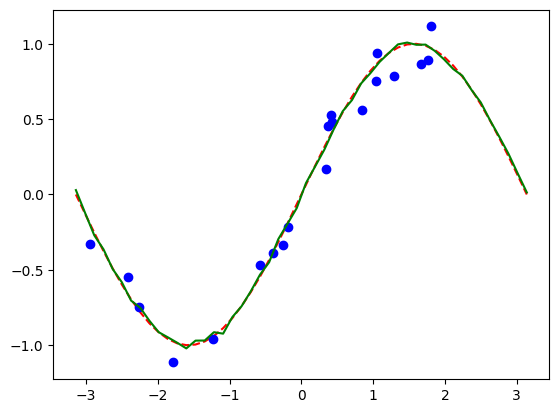

In [17]:
# 목표 함수, 데이터, 적합된 함수 그래프 그리기
# Plot target function
plt.plot(np.linspace(lb, ub), f(np.linspace(lb, ub)), "r--")

# Plot data
plt.plot(X, y, "bo")

# Plot fitted line
model3.eval()
y_ = []
for x in np.linspace(lb, ub):
    output = model3(Tensor([x]))
    y_ += [output.detach().numpy()[0]]
plt.plot(np.linspace(lb, ub), y_, "g-")
plt.show()

***

## 파트 2: MNIST 분류, 하이브리드 양자-고전 신경망

이 두 번째 부분에서는 `토치 커넥터(TorchConnector)`를 사용하여 하이브리드 양자-고전 신경망을 활용하여 MNIST 손글씨 숫자 데이터셋에서 더 복잡한 이미지 분류 작업을 수행하는 방법을 보여준다.

하이브리드 양자-고전 신경망에 대한 더 자세한 (사전-`토치 커넥터(TorchConnector)`) 설명은 [Qiskit 교과서 저장소](https://github.com/Qiskit/platypus/blob/main/notebooks/v2/ch-machine-learning/machine-learning-qiskit-pytorch.ipynb)의 해당 섹션을 확인할 수 있다.

In [18]:
# 추가 torch 임포트(DataLoader, optim, Conv2d 등)
# Additional torch-related imports
import torch
from torch import cat, no_grad, manual_seed
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.optim as optim
from torch.nn import (
    Module,
    Conv2d,
    Linear,
    Dropout2d,
    NLLLoss,
    MaxPool2d,
    Flatten,
    Sequential,
    ReLU,
)
import torch.nn.functional as F

### 단계 1: 훈련 및 테스트를 위한 데이터 로더(Data-loaders) 정의

우리는 `torchvision` [API](https://pytorch.org/vision/stable/datasets.html)를 활용하여 [MNIST 데이터셋](https://en.wikipedia.org/wiki/MNIST_database)의 부분집합을 직접 로드하고 훈련 및 테스트를 위해 torch `데이터 로더(DataLoader)`를 정의한다([링크](https://pytorch.org/docs/stable/data.html)).

In [19]:
# 훈련 데이터셋 설정(batch_size=1, n_samples=100, 숫자 0과 1)
# Train Dataset
# -------------

# Set train shuffle seed (for reproducibility)
manual_seed(42)

batch_size = 1
n_samples = 100  # We will concentrate on the first 100 samples

# Use pre-defined torchvision function to load MNIST train data
X_train = datasets.MNIST(
    root="./data", train=True, download=True, transform=transforms.Compose([transforms.ToTensor()])
)

# Filter out labels (originally 0-9), leaving only labels 0 and 1
idx = np.append(
    np.where(X_train.targets == 0)[0][:n_samples], np.where(X_train.targets == 1)[0][:n_samples]
)
X_train.data = X_train.data[idx]
X_train.targets = X_train.targets[idx]

# Define torch dataloader with filtered data
train_loader = DataLoader(X_train, batch_size=batch_size, shuffle=True)

100.0%
100.0%
100.0%
100.0%


빠른 시각화를 수행하면, 훈련 데이터셋이 손글씨 0과 1의 이미지로 구성되어 있음을 알 수 있다.

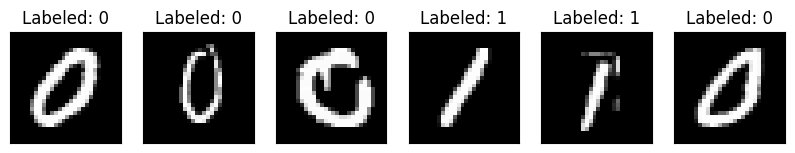

In [20]:
# 훈련 샘플 시각화
n_samples_show = 6

data_iter = iter(train_loader)
fig, axes = plt.subplots(nrows=1, ncols=n_samples_show, figsize=(10, 3))

while n_samples_show > 0:
    images, targets = data_iter.__next__()

    axes[n_samples_show - 1].imshow(images[0, 0].numpy().squeeze(), cmap="gray")
    axes[n_samples_show - 1].set_xticks([])
    axes[n_samples_show - 1].set_yticks([])
    axes[n_samples_show - 1].set_title("Labeled: {}".format(targets[0].item()))

    n_samples_show -= 1

In [21]:
# 테스트 데이터셋 설정(n_samples=50)
# Test Dataset
# -------------

# Set test shuffle seed (for reproducibility)
# manual_seed(5)

n_samples = 50

# Use pre-defined torchvision function to load MNIST test data
X_test = datasets.MNIST(
    root="./data", train=False, download=True, transform=transforms.Compose([transforms.ToTensor()])
)

# Filter out labels (originally 0-9), leaving only labels 0 and 1
idx = np.append(
    np.where(X_test.targets == 0)[0][:n_samples], np.where(X_test.targets == 1)[0][:n_samples]
)
X_test.data = X_test.data[idx]
X_test.targets = X_test.targets[idx]

# Define torch dataloader with filtered data
test_loader = DataLoader(X_test, batch_size=batch_size, shuffle=True)

### 단계 2: QNN과 하이브리드 모델 정의

이 두 번째 단계는 `토치 커넥터(TorchConnector)`의 힘을 보여준다. 양자 신경망 계층을 정의한 후(이 경우, `추정기QNN(EstimatorQNN)`), 우리는 `토치 커넥터(TorchConnector)(qnn)`로 토치 커넥터를 초기화하여 torch `모듈(Module)` 계층에 이를 포함시킬 수 있다.

**⚠️ 주의(Attention):**
하이브리드 모델에서 적절한 기울기 역전파(gradient backpropagation)를 갖기 위해, qnn 초기화 중에 초기 매개변수 `input_gradients`를 TRUE로 설정해야 한다.

In [22]:
# create_qnn() 함수 정의
# Define and create QNN
def create_qnn():
    feature_map = zz_feature_map(2)
    ansatz = real_amplitudes(2, reps=1)
    qc = QuantumCircuit(2)
    qc.compose(feature_map, inplace=True)
    qc.compose(ansatz, inplace=True)

    # REMEMBER TO SET input_gradients=True FOR ENABLING HYBRID GRADIENT BACKPROP
    qnn = EstimatorQNN(
        circuit=qc,
        input_params=feature_map.parameters,
        weight_params=ansatz.parameters,
        input_gradients=True,
        estimator=estimator,
    )
    return qnn


qnn4 = create_qnn()

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


In [23]:
# class Net(Module) - Conv2d와 QNN 하이브리드
# Define torch NN module


class Net(Module):
    def __init__(self, qnn):
        super().__init__()
        self.conv1 = Conv2d(1, 2, kernel_size=5)
        self.conv2 = Conv2d(2, 16, kernel_size=5)
        self.dropout = Dropout2d()
        self.fc1 = Linear(256, 64)
        self.fc2 = Linear(64, 2)  # 2-dimensional input to QNN
        self.qnn = TorchConnector(qnn)  # Apply torch connector, weights chosen
        # uniformly at random from interval [-1,1].
        self.fc3 = Linear(1, 1)  # 1-dimensional output from QNN

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = self.dropout(x)
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = self.qnn(x)  # apply QNN
        x = self.fc3(x)
        return cat((x, 1 - x), -1)


model4 = Net(qnn4)

### 단계 3: 훈련(Training)

In [24]:
# Adam 최적화기, NLLLoss, 훈련 루프
# Define model, optimizer, and loss function
optimizer = optim.Adam(model4.parameters(), lr=0.001)
loss_func = NLLLoss()

# Start training
epochs = 10  # Set number of epochs
loss_list = []  # Store loss history
model4.train()  # Set model to training mode

for epoch in range(epochs):
    total_loss = []
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad(set_to_none=True)  # Initialize gradient
        output = model4(data)  # Forward pass
        loss = loss_func(output, target)  # Calculate loss
        loss.backward()  # Backward pass
        optimizer.step()  # Optimize weights
        total_loss.append(loss.item())  # Store loss
    loss_list.append(sum(total_loss) / len(total_loss))
    print("Training [{:.0f}%]\tLoss: {:.4f}".format(100.0 * (epoch + 1) / epochs, loss_list[-1]))

Training [10%]	Loss: -1.1353
Training [20%]	Loss: -1.5443
Training [30%]	Loss: -1.7708
Training [40%]	Loss: -2.0303
Training [50%]	Loss: -2.2607
Training [60%]	Loss: -2.4529
Training [70%]	Loss: -2.6591
Training [80%]	Loss: -2.8520
Training [90%]	Loss: -3.0909
Training [100%]	Loss: -3.2875


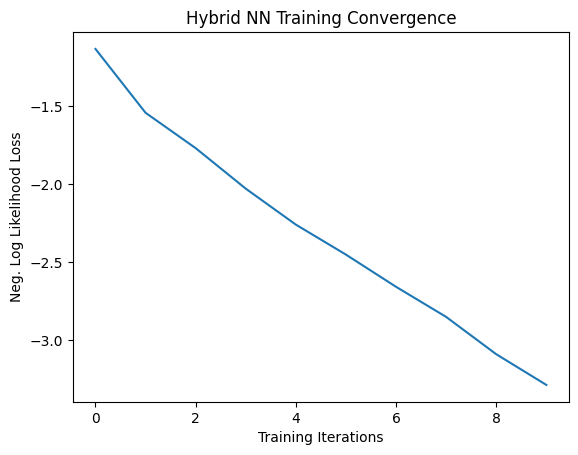

In [25]:
# 손실 수렴(Loss Convergence) 그래프 그리기
# Plot loss convergence
plt.plot(loss_list)
plt.title("Hybrid NN Training Convergence")
plt.xlabel("Training Iterations")
plt.ylabel("Neg. Log Likelihood Loss")
plt.show()

이제 훈련된 모델을 저장할 것이며, 이는 하이브리드 모델이 나중에 추론을 위해 어떻게 저장되고 재사용될 수 있는지를 보여주기 위함이다. 토치 커넥터(TorchConnector)를 사용할 때 하이브리드 모델을 저장하고 로드하려면, 모델을 저장하고 로드하는 파이토치 권장사항을 따르라.

In [26]:
# torch.save(model4.state_dict())로 훈련된 모델 저장
torch.save(model4.state_dict(), "model4.pt")

### 단계 4: 평가(Evaluation)

우리는 이전에 저장된 파일에서 상태를 로드하여 모델을 다시 만드는 것으로 시작한다. 다른 시뮬레이터나 실제 하드웨어를 사용하여 QNN 계층을 만들 수 있다. 그래서, 실제 클라우드에서 사용 가능한 하드웨어에서 모델을 훈련하고 추론을 위해 시뮬레이터를 사용하거나 그 반대를 할 수 있다. 단순함을 위해 위와 동일한 방식으로 새로운 양자 신경망을 만든다.

In [27]:
# model5 load_state_dict
qnn5 = create_qnn()
model5 = Net(qnn5)
model5.load_state_dict(torch.load("model4.pt"))

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


<All keys matched successfully>

In [28]:
# 테스트 셋에서 평가, 정확도 계산
model5.eval()  # set model to evaluation mode
with no_grad():

    correct = 0
    for batch_idx, (data, target) in enumerate(test_loader):
        output = model5(data)
        if len(output.shape) == 1:
            output = output.reshape(1, *output.shape)

        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()

        loss = loss_func(output, target)
        total_loss.append(loss.item())

    print(
        "Performance on test data:\n\tLoss: {:.4f}\n\tAccuracy: {:.1f}%".format(
            sum(total_loss) / len(total_loss), correct / len(test_loader) / batch_size * 100
        )
    )

Performance on test data:
	Loss: -3.3326
	Accuracy: 100.0%


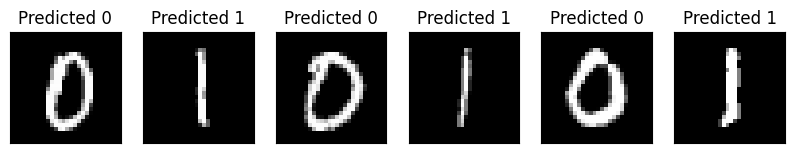

In [29]:
# 예측된 라벨 그래프 그리기
# Plot predicted labels

n_samples_show = 6
count = 0
fig, axes = plt.subplots(nrows=1, ncols=n_samples_show, figsize=(10, 3))

model5.eval()
with no_grad():
    for batch_idx, (data, target) in enumerate(test_loader):
        if count == n_samples_show:
            break
        output = model5(data[0:1])
        if len(output.shape) == 1:
            output = output.reshape(1, *output.shape)

        pred = output.argmax(dim=1, keepdim=True)

        axes[count].imshow(data[0].numpy().squeeze(), cmap="gray")

        axes[count].set_xticks([])
        axes[count].set_yticks([])
        axes[count].set_title("Predicted {}".format(pred.item()))

        count += 1

In [1]:
# 버전 정보 및 저작권을 표시한다(Display version information and copyright)
import tutorial_magics

%qiskit_version_table
%qiskit_copyright